# 03 — Courbes d'entraînement

KOMOSSI Sosso — Master BIG DATA IA, Institut ESI — UCAO-UUT, 2025-2026

Lit `models/pretrained/training_history.json`, produit par `scripts/train_model.py` (10 époques, sélection du meilleur checkpoint sur Val F1, early stopping patience 2). Aucune valeur recalculée.

In [1]:
import json, os
import pandas as pd
import matplotlib.pyplot as plt

ROOT = os.path.dirname(os.getcwd()) if os.path.basename(os.getcwd()) == 'notebooks' else os.getcwd()
with open(os.path.join(ROOT, 'models/pretrained/training_history.json')) as f:
    hist = pd.DataFrame(json.load(f))
hist

,epoch,train_f1,val_f1,val_precision,val_recall,val_auc,train_loss,duration_sec
0,1,0.9219,0.9321,0.9279,0.9370,0.9872,0.1810,3643.5
1,2,0.9569,0.9371,0.9221,0.9549,0.9892,0.1359,3645.2
2,3,0.9625,0.9392,0.9379,0.9407,0.9902,0.1352,3657.4
3,4,0.9691,0.9337,0.9546,0.9109,0.9892,0.1369,3696.0
4,5,0.9747,0.9383,0.9418,0.9344,0.9896,0.1512,3652.7
5,6,0.9793,0.9373,0.9313,0.9443,0.9888,0.1396,3662.8
6,7,0.9826,0.9374,0.9103,0.9706,0.9887,0.1270,3665.2
7,8,0.9851,0.9378,0.9231,0.9553,0.9892,0.1106,3675.7
8,9,0.9862,0.9372,0.9223,0.9549,0.9895,0.1014,3658.1
9,10,0.9890,0.9333,0.9481,0.9168,0.9891,0.0819,3669.4


## Train F1 vs Val F1 par époque

Le Train F1 progresse de manière quasi monotone tandis que le Val F1 plafonne tôt puis oscille légèrement à la baisse — signature classique d'un début de sur-apprentissage au-delà de l'époque retenue.

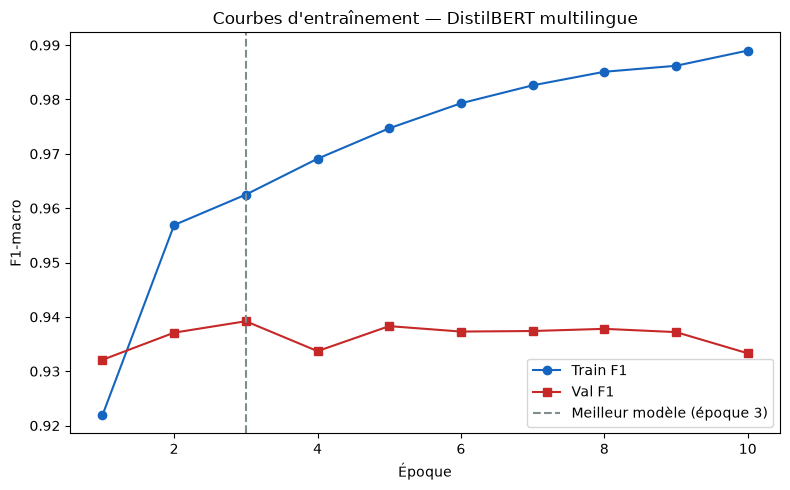

Meilleure époque : 3 (Val F1 = 0.9392)


In [2]:
best_epoch = int(hist.loc[hist.val_f1.idxmax(), 'epoch'])
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(hist.epoch, hist.train_f1, 'o-', label='Train F1', color='#1565C0')
ax.plot(hist.epoch, hist.val_f1, 's-', label='Val F1', color='#C62828')
ax.axvline(best_epoch, ls='--', color='#7F8C8D',
           label=f'Meilleur modèle (époque {best_epoch})')
ax.set_xlabel('Époque'); ax.set_ylabel('F1-macro')
ax.set_title("Courbes d'entraînement — DistilBERT multilingue")
ax.legend(); plt.tight_layout(); plt.show()
print(f'Meilleure époque : {best_epoch} (Val F1 = {hist.val_f1.max():.4f})')

## Perte d'entraînement (train_loss) et durée par époque

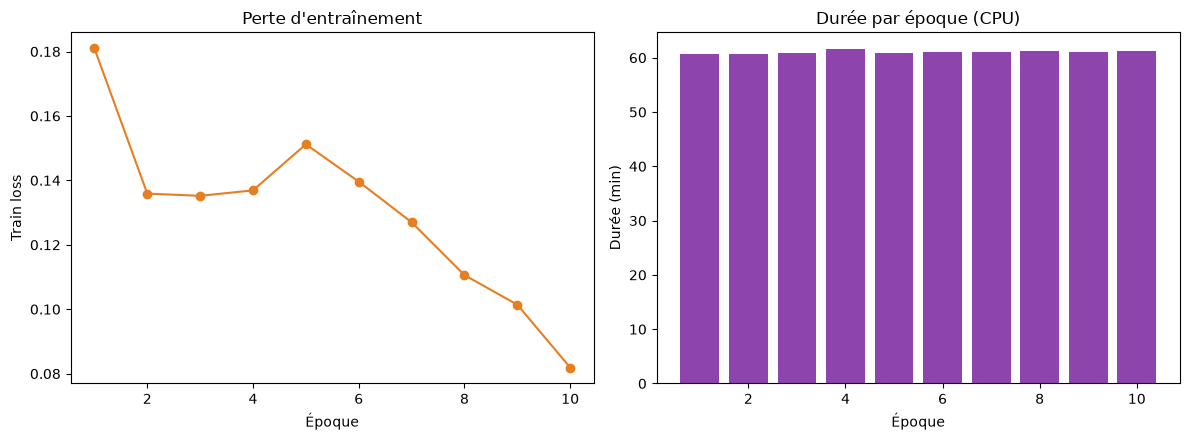

Durée totale d'entraînement : 10.2 h (61.0 min/époque en moyenne, CPU)


In [3]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.5))
ax1.plot(hist.epoch, hist.train_loss, 'o-', color='#E67E22')
ax1.set_xlabel('Époque'); ax1.set_ylabel('Train loss'); ax1.set_title('Perte d\'entraînement')
ax2.bar(hist.epoch, hist.duration_sec / 60, color='#8E44AD')
ax2.set_xlabel('Époque'); ax2.set_ylabel('Durée (min)'); ax2.set_title('Durée par époque (CPU)')
plt.tight_layout(); plt.show()
total_h = hist.duration_sec.sum() / 3600
mean_min = hist.duration_sec.mean() / 60
print(f"Durée totale d'entraînement : {total_h:.1f} h ({mean_min:.1f} min/époque en moyenne, CPU)")

## Précision / Rappel de validation par époque

Illustre l'arbitrage précision/rappel selon l'époque — pertinent pour justifier le choix du seuil de décision (`p_fake >= 0,75`, cf. `spark-app/src/nlp_classifier.py`) et la calibration probabiliste (`scripts/calibrate_model.py`, notebook non requis pour la relire : voir `reports/calibration.md`).

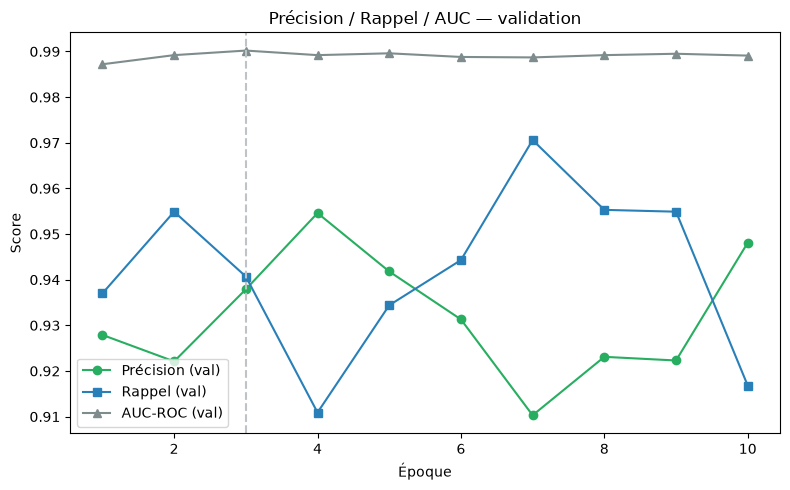

In [4]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(hist.epoch, hist.val_precision, 'o-', label='Précision (val)', color='#27AE60')
ax.plot(hist.epoch, hist.val_recall, 's-', label='Rappel (val)', color='#2980B9')
ax.plot(hist.epoch, hist.val_auc, '^-', label='AUC-ROC (val)', color='#7F8C8D')
ax.axvline(best_epoch, ls='--', color='#BDC3C7')
ax.set_xlabel('Époque'); ax.set_ylabel('Score'); ax.legend()
ax.set_title('Précision / Rappel / AUC — validation')
plt.tight_layout(); plt.show()

## Résumé

Le modèle finalement conservé (`model.save_pretrained()` déclenché uniquement à l'amélioration du Val F1) est celui de l'époque retenue ci-dessus — **pas** celui de la dernière époque. C'est ce checkpoint qui est évalué sur le jeu de test dans `02_error_analysis.ipynb` et servi en production (`models/pretrained/`, exporté en ONNX INT8 par `scripts/export_onnx.py`).